<a href="https://colab.research.google.com/github/ashok-bisht/Context-Aware_Misinformation_Detection_ML_and_Gen_AI/blob/main/notebooks/3.1_fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection Pipeline

End-to-end pipeline: load data from Google Drive → clean text → EDA →
classical ML models (LR / NB / SVM / RF / XGBoost) + DistilBERT →
model comparison → TF-IDF feature importance → export CSVs for Tableau →
pickle self-contained predictors for standalone use → Streamlit app.

**Expected input CSV schema:** `,title,text,label` (first column is an index),
`label = 0` → fake news, `label = 1` → true news.


## 0. Setup — install dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
!pip -q install -U scikit-learn xgboost spacy transformers datasets accelerate seaborn wordcloud
!pip uninstall -y -q torchaudio torchvision
!python -m spacy download en_core_web_sm -q


### Mount Google Drive

### Imports

In [ ]:
import os
import re
import sys
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


### Project configuration — **edit these paths to match your Drive layout**

Everything the pipeline reads/writes lives under `BASE_DIR`. Sub-folders are
created automatically if missing.

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Fake News Predictor"

INPUT_CSV      = f"{BASE_DIR}/data/raw/WELFake_Dataset.csv"          # your source csv (,title,text,label)
PROCESSED_DIR  = f"{BASE_DIR}/data/processed"
CLEANED_CSV    = f"{PROCESSED_DIR}/cleaned_data.csv"

CHARTS_DIR     = f"{BASE_DIR}/outputs/charts"
TABLEAU_DIR    = f"{BASE_DIR}/outputs/tableau_data"
REPORTS_DIR    = f"{BASE_DIR}/outputs/reports"
PICKLES_DIR    = f"{BASE_DIR}/models/pickles"
PIPELINE_MODULE_PATH = f"{BASE_DIR}/fake_news_pipeline.py"      # importable module for pickled predictors

for d in [PROCESSED_DIR, CHARTS_DIR, TABLEAU_DIR, REPORTS_DIR, PICKLES_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
LABEL_MEANING = {0: "Fake News", 1: "True News"}
print("Project folders ready under:", BASE_DIR)


## 1. Load data & build `content` field

In [ ]:
raw_df = pd.read_csv(INPUT_CSV, index_col=0)  # first unnamed column is the index
print(raw_df.shape)
raw_df.head()


In [ ]:
assert {"title", "text", "label"}.issubset(raw_df.columns), \
    f"Expected columns title/text/label, got: {list(raw_df.columns)}"

df = raw_df.copy()
df["title"] = df["title"].fillna("")
df["text"]  = df["text"].fillna("")
df["content"] = (df["title"].str.strip() + ". " + df["text"].str.strip()).str.strip()

df = df[["content", "label"]].dropna(subset=["content", "label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)

print(df.shape)
print(df["label"].value_counts())
df.head()


## 2. Write the shared `fake_news_pipeline.py` module to Drive

This file is the **single source of truth** for cleaning + spaCy lemmatization
+ the `FakeNewsPredictor` bundle class. It is written programmatically
(instead of via `%%writefile`, which can't interpolate the `PIPELINE_MODULE_PATH`
variable) so the exact code used here for training is also what gets imported
later when a pickle is unpickled — in this notebook, in a standalone script,
or in Streamlit.

In [ ]:
PIPELINE_SOURCE = r'''"""
fake_news_pipeline.py
----------------------
Single source of truth for the fake-news detection inference pipeline.
Must be importable (on sys.path) wherever a FakeNewsPredictor pickle is loaded.
"""

import re


def strip_journalism_fingerprints(text, publishers_to_scrub=None):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"\.\s*featured\s+image.*$", ".", text, flags=re.IGNORECASE | re.MULTILINE)
    text = re.sub(r"\s*\[\s*video\s*\]\s*", " ", text, flags=re.IGNORECASE).strip()

    text = text.strip()
    text = text.replace("\u00a0", " ")

    punctuation_map = {
        "\u2019": "'", "\u2018": "'",
        "\u201c": '"', "\u201d": '"',
        "\u2013": "-", "\u2014": "-",
    }
    for curly, straight in punctuation_map.items():
        text = text.replace(curly, straight)
    text = text.replace("\u00e2\u20ac\u2122", "'")

    text = re.sub(
        r"\b(isn|don|didn|doesn|can|wasn|weren|haven|hasn|hadn|won|wouldn|shouldn|couldn|aren)\s+t\b",
        r"\1't", text, flags=re.IGNORECASE
    )
    text = re.sub(r"\b(don|didn|doesn|isn|can)\s*'\s*t\b", r"\1't", text, flags=re.IGNORECASE)

    leading_bracket_pattern = r"^\([^)]+\)\s*"
    text = re.sub(leading_bracket_pattern, "", text)

    dateline_pattern = r"^[A-Z\s,]+(?:\s\([^)]+\))?\s*[\s\-\-\u2013\u2014]\s*"
    text = re.sub(dateline_pattern, "", text)

    byline_pattern = r"(?:By\s+[A-Za-z\s]+)?\s*\([^)]+\)"
    text = re.sub(byline_pattern, "", text)

    if publishers_to_scrub:
        escaped_publishers = [re.escape(pub) for pub in publishers_to_scrub]
        scrub_pattern = r"\b(" + "|".join(escaped_publishers) + r")\b"
        text = re.sub(scrub_pattern, "XYZ", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text).strip()
    return text


def spacy_lemmatize(text, nlp, min_token_len=2):
    if not text:
        return ""
    doc = nlp(text)
    tokens = [
        tok.lemma_.lower().strip()
        for tok in doc
        if not tok.is_stop
        and not tok.is_punct
        and not tok.is_space
        and not tok.like_num
        and len(tok.lemma_.strip()) >= min_token_len
    ]
    return " ".join(tokens)


class FakeNewsPredictor:
    """Bundles cleaning + spaCy lemmatization + fitted TF-IDF + fitted classical model.
    predict() takes raw text and returns {label, meaning, confidence}."""

    LABEL_MEANING = {0: "Fake News", 1: "True News"}

    def __init__(self, tfidf_vectorizer, model, model_name="model",
                 spacy_model_name="en_core_web_sm", publishers_to_scrub=None,
                 label_map=None):
        self.tfidf_vectorizer = tfidf_vectorizer
        self.model = model
        self.model_name = model_name
        self.spacy_model_name = spacy_model_name
        self.publishers_to_scrub = publishers_to_scrub
        self.label_map = label_map or self.LABEL_MEANING
        self._nlp = None

    def _get_nlp(self):
        if self._nlp is None:
            import spacy
            try:
                self._nlp = spacy.load(self.spacy_model_name, disable=["ner", "parser"])
            except OSError:
                import subprocess
                subprocess.run(["python", "-m", "spacy", "download", self.spacy_model_name], check=True)
                self._nlp = spacy.load(self.spacy_model_name, disable=["ner", "parser"])
        return self._nlp

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_nlp"] = None
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        self._nlp = None

    def preprocess(self, raw_text):
        cleaned = strip_journalism_fingerprints(raw_text, self.publishers_to_scrub)
        lemmatized = spacy_lemmatize(cleaned, self._get_nlp())
        return lemmatized

    def predict(self, raw_text):
        processed = self.preprocess(raw_text)
        X = self.tfidf_vectorizer.transform([processed])

        pred_label = int(self.model.predict(X)[0])

        if hasattr(self.model, "predict_proba"):
            proba = self.model.predict_proba(X)[0]
            confidence = float(max(proba))
        elif hasattr(self.model, "decision_function"):
            import numpy as np
            score = self.model.decision_function(X)[0]
            confidence = float(1 / (1 + np.exp(-score)))
        else:
            confidence = 1.0

        return {
            "label": pred_label,
            "meaning": self.label_map.get(pred_label, str(pred_label)),
            "confidence": round(confidence, 4),
        }

    def predict_batch(self, raw_texts):
        return [self.predict(t) for t in raw_texts]

    def __repr__(self):
        return f"<FakeNewsPredictor model={self.model_name}>"
'''

with open(PIPELINE_MODULE_PATH, "w") as f:
    f.write(PIPELINE_SOURCE)

print("Wrote pipeline module to:", PIPELINE_MODULE_PATH)


In [ ]:
# Make the Drive folder importable, then import the freshly written module
import importlib

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

import fake_news_pipeline as fnp
importlib.reload(fnp)

# sanity check on the provided cleanup function
sample = "NEW YORK (Reuters) - The senator said he isn t going to run. [VIDEO] Featured image via Al Drago-Pool/Getty Images"
print(fnp.strip_journalism_fingerprints(sample))


## 3. Apply cleaning to `content` and save the cleaned CSV

In [ ]:
PUBLISHERS_TO_SCRUB =  ["Reuters", "CNN", "Associated Press", "BBC"]  # e.g. ["Reuters", "Al Jazeera"] if you want publisher names scrubbed

df["content_clean"] = df["content"].apply(lambda t: fnp.strip_journalism_fingerprints(t, PUBLISHERS_TO_SCRUB))

# drop rows that became empty after cleaning
df = df[df["content_clean"].str.strip().str.len() > 0].reset_index(drop=True)

cleaned_df = df[["content_clean", "label"]].rename(columns={"content_clean": "content"})
cleaned_df.to_csv(CLEANED_CSV, index=False)
print("Saved cleaned data ->", CLEANED_CSV, cleaned_df.shape)
cleaned_df.head()


## 4. Exploratory Data Analysis

In [ ]:
cleaned_df["word_count"] = cleaned_df["content"].str.split().str.len()
cleaned_df["char_count"] = cleaned_df["content"].str.len()
cleaned_df["label_name"] = cleaned_df["label"].map(LABEL_MEANING)

eda_summary = cleaned_df.groupby("label_name").agg(
    n_articles=("content", "count"),
    avg_word_count=("word_count", "mean"),
    median_word_count=("word_count", "median"),
    avg_char_count=("char_count", "mean"),
).reset_index()
eda_summary.to_csv(f"{TABLEAU_DIR}/eda_summary.csv", index=False)
eda_summary


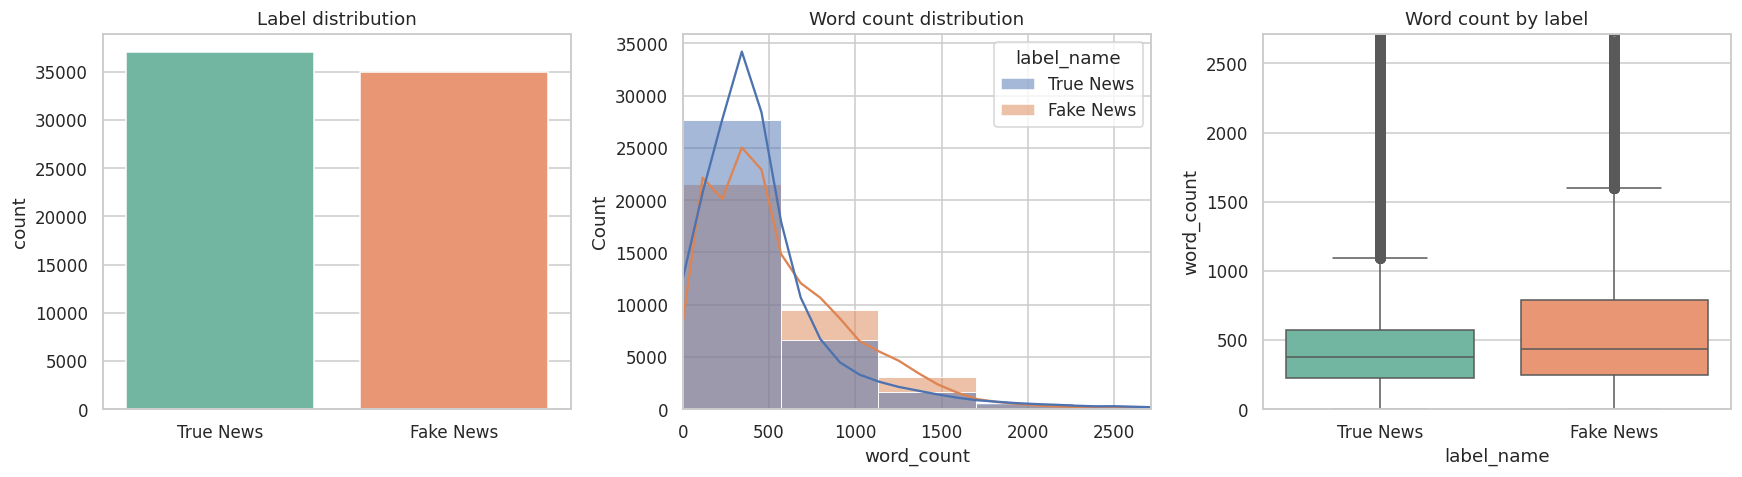

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=cleaned_df, x="label_name", ax=axes[0], palette="Set2")
axes[0].set_title("Label distribution")
axes[0].set_xlabel("")

sns.histplot(data=cleaned_df, x="word_count", hue="label_name", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Word count distribution")
axes[1].set_xlim(0, cleaned_df["word_count"].quantile(0.99))

sns.boxplot(data=cleaned_df, x="label_name", y="word_count", ax=axes[2], palette="Set2")
axes[2].set_title("Word count by label")
axes[2].set_ylim(0, cleaned_df["word_count"].quantile(0.99))

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/eda_overview.png", bbox_inches="tight")
plt.show()

# raw per-article data for Tableau
cleaned_df[["label", "label_name", "word_count", "char_count"]].to_csv(
    f"{TABLEAU_DIR}/eda_per_article.csv", index=False
)


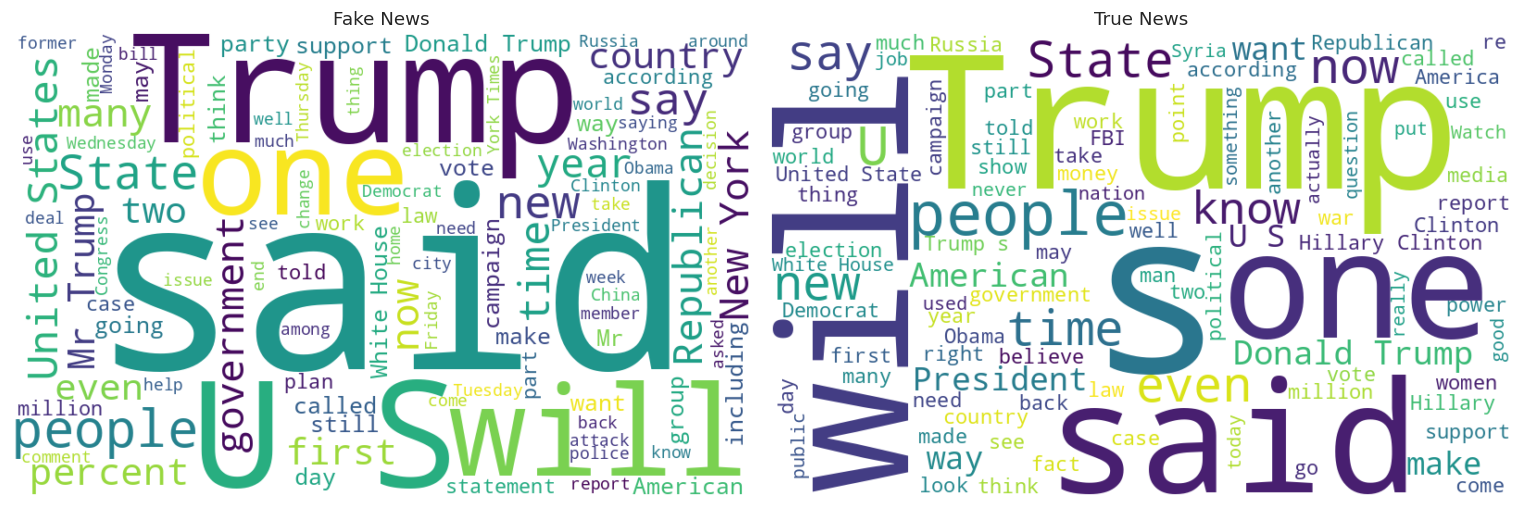

In [12]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lbl in zip(axes, [0, 1]):
    text_blob = " ".join(cleaned_df.loc[cleaned_df["label"] == lbl, "content"].sample(
        min(2000, (cleaned_df["label"] == lbl).sum()), random_state=RANDOM_STATE
    ))
    wc = WordCloud(width=800, height=500, background_color="white", max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(LABEL_MEANING[lbl])

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/wordclouds.png", bbox_inches="tight")
plt.show()


## 5. spaCy preprocessing + TF-IDF vectorization

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# batched lemmatization for speed
def batch_lemmatize(texts, nlp, batch_size=200, n_process=1):
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        tokens = [
            tok.lemma_.lower().strip()
            for tok in doc
            if not tok.is_stop and not tok.is_punct and not tok.is_space
            and not tok.like_num and len(tok.lemma_.strip()) >= 2
        ]
        out.append(" ".join(tokens))
    return out

cleaned_df["content_lemmatized"] = batch_lemmatize(cleaned_df["content"].tolist(), nlp)
cleaned_df[["content_lemmatized", "label"]].to_csv(f"{PROCESSED_DIR}/lemmatized_data.csv", index=False)
cleaned_df[["content", "content_lemmatized", "label"]].head()


In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    cleaned_df["content_lemmatized"], cleaned_df["label"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=cleaned_df["label"]
)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.9)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Train shape:", X_train_tfidf.shape, " Test shape:", X_test_tfidf.shape)


## 6. Train classical models: LR / NB / SVM / RF / XGBoost

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ),
}

trained_models = {}
predictions = {}

for name, clf in models.items():
    print(f"Training {name} ...")
    clf.fit(X_train_tfidf, y_train)
    trained_models[name] = clf
    predictions[name] = clf.predict(X_test_tfidf)

print("Done training all classical models.")


### Classification reports

In [ ]:
reports = {}
metrics_rows = []

for name, y_pred in predictions.items():
    report_dict = classification_report(y_test, y_pred, target_names=["Fake News", "True News"], output_dict=True)
    reports[name] = report_dict
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred, target_names=["Fake News", "True News"]))

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
    metrics_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("f1_score", ascending=False).reset_index(drop=True)
metrics_df.to_csv(f"{REPORTS_DIR}/classical_model_metrics.csv", index=False)
metrics_df.to_csv(f"{TABLEAU_DIR}/classical_model_metrics.csv", index=False)
metrics_df


In [ ]:
metrics_melted = metrics_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1_score"],
                                  var_name="metric", value_name="score")

plt.figure(figsize=(11, 5))
sns.barplot(data=metrics_melted, x="model", y="score", hue="metric")
plt.title("Classical model comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/classical_model_comparison.png", bbox_inches="tight")
plt.show()


## 7. Top 10 TF-IDF features per label

In [ ]:
lr_for_features = trained_models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_for_features.coef_[0]  # positive -> class 1 (True News), negative -> class 0 (Fake News)

top10_true = pd.DataFrame({
    "feature": feature_names[np.argsort(coefs)[-10:][::-1]],
    "weight": np.sort(coefs)[-10:][::-1],
    "label": "True News",
})
top10_fake = pd.DataFrame({
    "feature": feature_names[np.argsort(coefs)[:10]],
    "weight": np.sort(coefs)[:10],
    "label": "Fake News",
})
top_features_df = pd.concat([top10_fake, top10_true], ignore_index=True)
top_features_df.to_csv(f"{TABLEAU_DIR}/top10_tfidf_features.csv", index=False)
top_features_df


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.barplot(data=top10_fake.sort_values("weight"), x="weight", y="feature", ax=axes[0], color="#e15759")
axes[0].set_title("Top 10 TF-IDF features — Fake News")
axes[0].set_xlabel("LR coefficient (negative = fake)")

sns.barplot(data=top10_true.sort_values("weight"), x="weight", y="feature", ax=axes[1], color="#4e79a7")
axes[1].set_title("Top 10 TF-IDF features — True News")
axes[1].set_xlabel("LR coefficient (positive = true)")

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/top10_tfidf_features.png", bbox_inches="tight")
plt.show()


## 8. DistilBERT fine-tuning

In [ ]:
import torch
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    TrainingArguments, Trainer
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# DistilBERT uses the same cleaned text as the classical models but WITHOUT
# lemmatization (transformers work better on natural text).
bert_df = cleaned_df[["content", "label"]].rename(columns={"content": "text"})
bert_train_df, bert_test_df = train_test_split(
    bert_df, test_size=0.2, random_state=RANDOM_STATE, stratify=bert_df["label"]
)

train_ds = Dataset.from_pandas(bert_train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(bert_test_df.reset_index(drop=True))

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir=f"{REPORTS_DIR}/distilbert_checkpoints",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to=[],
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()


In [ ]:
bert_eval = trainer.evaluate()
print(bert_eval)

bert_preds_logits = trainer.predict(test_ds).predictions
bert_preds = np.argmax(bert_preds_logits, axis=1)
print(classification_report(bert_test_df["label"], bert_preds, target_names=["Fake News", "True News"]))

bert_precision, bert_recall, bert_f1, _ = precision_recall_fscore_support(
    bert_test_df["label"], bert_preds, average="weighted"
)
bert_row = {
    "model": "DistilBERT",
    "accuracy": accuracy_score(bert_test_df["label"], bert_preds),
    "precision": bert_precision,
    "recall": bert_recall,
    "f1_score": bert_f1,
}
print(bert_row)


## 9. Final model comparison — all 6 models

In [ ]:
final_metrics_df = pd.concat([metrics_df, pd.DataFrame([bert_row])], ignore_index=True)
final_metrics_df = final_metrics_df.sort_values("f1_score", ascending=False).reset_index(drop=True)
final_metrics_df.to_csv(f"{REPORTS_DIR}/final_model_metrics.csv", index=False)
final_metrics_df.to_csv(f"{TABLEAU_DIR}/final_model_metrics.csv", index=False)

best_model_name = final_metrics_df.iloc[0]["model"]
print("Best model by weighted F1:", best_model_name)
final_metrics_df


In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=final_metrics_df, x="model", y="f1_score", palette="viridis")
plt.title(f"Model comparison (weighted F1) — best: {best_model_name}")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/final_model_comparison.png", bbox_inches="tight")
plt.show()


## 10. Additional performance charts — confusion matrices & ROC curves

In [ ]:
fig, axes = plt.subplots(1, len(predictions), figsize=(4.2 * len(predictions), 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/confusion_matrices.png", bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(7, 6))
roc_rows = []
for name, clf in trained_models.items():
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = clf.decision_function(X_test_tfidf)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    roc_rows.append({"model": name, "auc": roc_auc})

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — classical models")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/roc_curves.png", bbox_inches="tight")
plt.show()

pd.DataFrame(roc_rows).to_csv(f"{TABLEAU_DIR}/roc_auc.csv", index=False)


## 11. Pickle each classical model as a self-contained `FakeNewsPredictor`

Each pickle bundles: cleaning (`strip_journalism_fingerprints`) + spaCy
lemmatization + the fitted TF-IDF vectorizer + the fitted classical model.
Loading the pickle and calling `.predict(raw_text)` returns
`{"label": int, "meaning": str, "confidence": float}` — no other setup needed
beyond having `fake_news_pipeline.py` importable.

In [ ]:
SAFE_NAME = {
    "Logistic Regression": "logistic_regression",
    "Naive Bayes": "naive_bayes",
    "SVM": "svm",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
}

pickle_paths = {}
for name, clf in trained_models.items():
    predictor = fnp.FakeNewsPredictor(
        tfidf_vectorizer=tfidf,
        model=clf,
        model_name=name,
        spacy_model_name="en_core_web_sm",
        publishers_to_scrub=PUBLISHERS_TO_SCRUB,
        label_map=LABEL_MEANING,
    )
    out_path = f"{PICKLES_DIR}/{SAFE_NAME[name]}_pipeline.pkl"
    with open(out_path, "wb") as f:
        pickle.dump(predictor, f)
    pickle_paths[name] = out_path
    print("Saved:", out_path)


### Sanity check — load a pickle back and predict on raw text

In [ ]:
with open(pickle_paths["Logistic Regression"], "rb") as f:
    loaded_predictor = pickle.load(f)

sample_text = "NEW YORK (Reuters) - Scientists announced a breakthrough today. [VIDEO] Featured image via Getty Images"
result = loaded_predictor.predict(sample_text)
print(result)

# swap to a different pickle file — same .predict() interface
with open(pickle_paths["XGBoost"], "rb") as f:
    loaded_xgb_predictor = pickle.load(f)
print(loaded_xgb_predictor.predict(sample_text))


## 12. Outputs summary

| Artifact | Path |
|---|---|
| Cleaned CSV | `CLEANED_CSV` |
| Lemmatized CSV | `PROCESSED_DIR/lemmatized_data.csv` |
| EDA data for Tableau | `TABLEAU_DIR/eda_summary.csv`, `eda_per_article.csv` |
| Classical model metrics | `TABLEAU_DIR/classical_model_metrics.csv` |
| Final comparison (incl. DistilBERT) | `TABLEAU_DIR/final_model_metrics.csv` |
| Top-10 TF-IDF features | `TABLEAU_DIR/top10_tfidf_features.csv` |
| ROC AUC values | `TABLEAU_DIR/roc_auc.csv` |
| Charts (PNG) | `CHARTS_DIR/*.png` |
| Pickled predictors | `PICKLES_DIR/*_pipeline.pkl` |
| Shared pipeline module | `PIPELINE_MODULE_PATH` |

Use the `streamlit_app.py` (delivered alongside this notebook) to serve any
of the pickles interactively — just change the model file path in the sidebar.
